# Sentiment analysis - CNN + LSTM

- Họ tên: Lê Trung Kiên
- Mã số sinh viên: 23127075
- Bài toán: Phân loại sắc thái phản hồi sinh viên tiếng Việt thành 3 lớp: positive, negative, neutral
- Dataset sử dụng: UIT-VSFC - Vietnamese Students' Feedback Corpus for Sentiment Analysis
- Mô hình triển khai: Multi-channel LSTM-CNN theo bài báo MultiChannel

## 1. Thông tin bài toán và dataset

Bài toán text classification được chọn là sentiment analysis cho tiếng Việt trên bộ dữ liệu UIT-VSFC (Vietnamese Students' Feedback Corpus for Sentiment Analysis). Mỗi câu phản hồi của sinh viên về môn học / giảng viên được gán một trong ba nhãn:

- `positive`: phản hồi tích cực
- `negative`: phản hồi tiêu cực
- `neutral`: phản hồi trung lập

Notebook này dùng kiến trúc CNN + LSTM theo bài báo *Multi-channel LSTM-CNN model for Vietnamese sentiment analysis* và code tham khảo từ repo MultiChannel, nhưng áp dụng vào bài toán phân loại sentiment của dataset UIT-VSFC.

Dataset UIT-VSFC đã được tải sẵn và đặt trong thư mục `data` của bài nộp dưới dạng CSV:

- `UIT-VSFC_train.csv`: tập train
- `UIT-VSFC_valid.csv`: tập validation do dataset cung cấp
- `UIT-VSFC_test.csv`: tập test do dataset cung cấp

Mỗi file CSV có hai cột chính:

- `text`: câu phản hồi tiếng Việt
- `label`: nhãn sentiment (`positive`, `negative`, `neutral`)

UIT-VSFC trong notebook này là câu tiếng Việt dạng thường và được lưu theo split train / validation / test, không cần tách thành nhiều file theo nhãn. Notebook đọc trực tiếp CSV, xử lý missing value nếu có, vector hóa bằng `TextVectorization`, xây dựng mô hình CNN + LSTM theo paper và đánh giá bằng accuracy, precision, recall, F1-score và confusion matrix.

# 2. Setup

## 2.1. Cấu trúc thư mục khuyến nghị

Để notebook chạy đúng đường dẫn tương đối, nên mở terminal/Jupyter ngay trong thư mục `23127075`. Cấu trúc khuyến nghị:

```text
23127075/
|-- 23127075.ipynb
|-- .venv/                  # tạo sau bằng cell setup
|-- data/
|   |-- UIT-VSFC_train.csv
|   |-- UIT-VSFC_valid.csv
|   |-- UIT-VSFC_test.csv
|-- artifacts/
|   |-- checkpoints/
|   |   |-- vietnamese_sentiment_best.weights.h5
|   |   |-- cv_fold_1_best.weights.h5
|   |   |-- ...
```

Notebook dùng `DATA_ROOT = Path('data')`, nên nếu chạy từ thư mục khác thì có thể bị lỗi không tìm thấy data. Cách chắc ăn nhất là `cd` vào thư mục `23127075`, kích hoạt `.venv`, rồi mở Jupyter từ đó.

## 2.2. Hướng dẫn chạy notebook

Phần này dành cho giảng viên chấm hoặc người muốn chạy lại toàn bộ notebook trên máy local/Colab. Sau khi giải nén hoặc clone project, cần có file `23127075.ipynb` và thư mục `data`.

Có hai cell setup riêng:

- **Cell 2.2.1 - Tạo virtual environment**: chỉ dùng khi chạy local bằng VS Code/Jupyter. Trên Google Colab thì bỏ qua cell này.
- **Cell 2.2.2 - Cài thư viện cần thiết**: dùng để cài các package trong biến `REQUIRED_PACKAGES`. Trên Colab có thể chạy cell này trực tiếp.

Nếu chạy local:

1. Mở terminal trong thư mục `23127075`.
2. Chạy cell 2.2.1 để tạo `.venv` và đăng ký kernel `Python 23127075`.
3. Chọn kernel `Python 23127075`, restart kernel.
4. Chạy cell 2.2.2 để cài thư viện vào kernel đang chọn.
5. Chạy tiếp notebook từ phần `## 3. Import thư viện`.

Nếu chạy trên Colab:

1. Upload notebook và thư mục `data`.
2. Bỏ qua cell 2.2.1.
3. Chạy cell 2.2.2.
4. Chạy tiếp notebook từ phần `## 3. Import thư viện`.

Có thể kiểm tra notebook đang dùng đúng môi trường local bằng:

```python
import sys
print(sys.executable)
```

Nếu chạy local và đường dẫn in ra kết thúc bằng `.venv\Scripts\python.exe` thì notebook đang dùng đúng virtual environment của bài nộp.

In [1]:
# 2.2.1. Local only: tạo virtual environment và đăng ký Jupyter kernel.
# Trên Google Colab: bỏ qua cell này.
from pathlib import Path
import os
import subprocess
import sys

PROJECT_DIR = Path.cwd()
VENV_DIR = PROJECT_DIR / '.venv'

if 'google.colab' in sys.modules:
    print('Đang chạy trên Google Colab: bỏ qua bước tạo .venv.')
else:
    if not VENV_DIR.exists():
        print(f'Tạo virtual environment tại: {VENV_DIR}')
        subprocess.check_call([sys.executable, '-m', 'venv', str(VENV_DIR)])
    else:
        print(f'Virtual environment đã tồn tại: {VENV_DIR}')

    venv_python = VENV_DIR / ('Scripts/python.exe' if os.name == 'nt' else 'bin/python')

    print('Cài/cập nhật pip trong .venv...')
    subprocess.check_call([str(venv_python), '-m', 'pip', 'install', '--upgrade', 'pip'])

    print('Cài ipykernel trong .venv...')
    subprocess.check_call([str(venv_python), '-m', 'pip', 'install', 'ipykernel'])

    print('Đăng ký Jupyter kernel: Python 23127075')
    subprocess.check_call([
        str(venv_python), '-m', 'ipykernel', 'install', '--user',
        '--name', '23127075-venv', '--display-name', 'Python 23127075'
    ])

    print('Hoàn tất tạo .venv.')
    print('Bước tiếp theo: chọn kernel "Python 23127075", restart kernel, rồi chạy cell 2.2.2 để cài thư viện.')

Virtual environment đã tồn tại: d:\Sentiment-analysis--CNN-LSTM\23127075\.venv
Cài/cập nhật pip trong .venv...
Cài ipykernel trong .venv...
Đăng ký Jupyter kernel: Python 23127075
Hoàn tất tạo .venv.
Bước tiếp theo: chọn kernel "Python 23127075", restart kernel, rồi chạy cell 2.2.2 để cài thư viện.


In [2]:
# 2.2.2. Cài thư viện cần thiết vào Python/kernel hiện tại.
# Local: chạy sau khi đã chọn kernel "Python 23127075".
# Colab: có thể chạy trực tiếp cell này.
import subprocess
import sys

REQUIRED_PACKAGES = [
    'numpy',
    'pandas',
    'scikit-learn',
    'matplotlib',
    'seaborn',
    'tensorflow',
    'notebook',
    'ipykernel',
]

print('Python executable:', sys.executable)
print('Cài/cập nhật các thư viện cần thiết...')
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--upgrade', *REQUIRED_PACKAGES])
print('Hoàn tất cài thư viện.')

Python executable: d:\Sentiment-analysis--CNN-LSTM\23127075\.venv\Scripts\python.exe
Cài/cập nhật các thư viện cần thiết...
Hoàn tất cài thư viện.


## 3. Import thư viện

Các thư viện cần thiết đã được khai báo và cài trong cell 2.2.2 bằng biến `REQUIRED_PACKAGES`.

Nếu chạy local trên máy mới, hãy tạo `.venv`, chọn kernel `Python 23127075`, chạy cell cài thư viện, rồi chạy tiếp từ cell import bên dưới. Nếu chạy Colab, bỏ qua cell tạo `.venv` và chỉ cần chạy cell cài thư viện.

In [3]:
import sys
print(sys.executable)

d:\Sentiment-analysis--CNN-LSTM\23127075\.venv\Scripts\python.exe


In [4]:
from pathlib import Path
import tempfile
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers, Model

SEED = 1337
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

def safe_print(*values):
    safe_values = [str(value).encode('ascii', errors='ignore').decode('ascii') for value in values]
    print(*safe_values)

print('TensorFlow:', tf.__version__)

TensorFlow: 2.21.0


## 4. Cấu hình thí nghiệm

Paper và code gốc `MultiChannel/cnn_lstm.py` dùng các thông số chính sau:

- Vocabulary size: `21540`
- Độ dài câu sau padding/truncating: `400`
- Embedding dimension: `200`
- CNN kernel sizes: `3, 5, 7`
- Số filter mỗi kernel size: `150`
- LSTM units: `128`
- Dense hidden layer: `200` trong code gốc, tương ứng `hidden_dims * 2` với `hidden_dims = 100`
- Dropout: `0.2`
- Optimizer: `Adamax`

Notebook giữ các thông số này để kiến trúc sát với bài báo và code MultiChannel nhất có thể.


In [5]:
DATA_ROOT_CANDIDATES = [Path('data'), Path('23127075') / 'data']
DATA_ROOT = next((path for path in DATA_ROOT_CANDIDATES if path.exists()), DATA_ROOT_CANDIDATES[0])
TRAIN_FILE = DATA_ROOT / 'UIT-VSFC_train.csv'
VALID_FILE = DATA_ROOT / 'UIT-VSFC_valid.csv'
TEST_FILE = DATA_ROOT / 'UIT-VSFC_test.csv'


def get_writable_artifact_dir(preferred_dir=Path('artifacts')):
    preferred_dir = Path(preferred_dir)
    fallback_dir = Path(tempfile.gettempdir()) / '23127075_artifacts'

    for candidate in [preferred_dir, fallback_dir]:
        try:
            candidate.mkdir(parents=True, exist_ok=True)
            test_file = candidate / '.write_test'
            test_file.write_text('ok', encoding='utf-8')
            test_file.unlink()
            if candidate != preferred_dir:
                safe_print(f'Cannot write to {preferred_dir}; using temp artifact dir: {candidate}')
            return candidate
        except OSError:
            continue

    raise PermissionError('Không tìm được thư mục có quyền ghi để lưu artifact.')


ARTIFACT_DIR = get_writable_artifact_dir(Path('artifacts'))
CHECKPOINT_DIR = ARTIFACT_DIR / 'checkpoints'

MAX_TOKENS = 21_540
MAX_LEN = 400
EMBEDDING_DIM = 200
CNN_FILTERS = 150
CNN_KERNEL_SIZES = [3, 5, 7]
LSTM_UNITS = 128
DENSE_UNITS = 200
DROPOUT_RATE = 0.2

BATCH_SIZE = 32
EPOCHS = 14

CLASS_NAMES = ['negative', 'positive', 'neutral']
LABEL_TO_ID = {label: idx for idx, label in enumerate(CLASS_NAMES)}
ID_TO_LABEL = {idx: label for label, idx in LABEL_TO_ID.items()}

assert DATA_ROOT.exists(), f'Không tìm thấy thư mục dữ liệu: {DATA_ROOT}'
for path in [TRAIN_FILE, VALID_FILE, TEST_FILE]:
    assert path.exists(), f'Không tìm thấy file dữ liệu: {path}'

## 5. Load dữ liệu từ file CSV

UIT-VSFC đã cung cấp sẵn ba split: train, validation và test. Vì vậy notebook không cần tự tách 10% train ra validation như code MultiChannel gốc.

Hàm dưới đây đọc từng file CSV, giữ hai cột `text` và `label`, bỏ dòng thiếu dữ liệu nếu có, chuyển text về lowercase và đổi nhãn chữ sang nhãn số để train bằng `sparse_categorical_crossentropy`.

Quy ước nhãn số:

- `negative` -> `0`
- `positive` -> `1`
- `neutral` -> `2`

In [6]:
def read_uit_vsfc_csv(path: Path):
    df = pd.read_csv(path)
    required_columns = {'text', 'label'}
    missing_columns = required_columns - set(df.columns)
    if missing_columns:
        raise ValueError(f'{path} thiếu cột: {missing_columns}')

    original_len = len(df)
    df = df[['text', 'label']].dropna().copy()
    dropped = original_len - len(df)
    if dropped:
        print(f'Dropped {dropped} empty row(s) from {path.name}')

    df['text'] = df['text'].astype(str).str.strip().str.lower()
    df['label'] = df['label'].astype(str).str.strip().str.lower()
    df = df[df['text'] != '']

    unknown_labels = sorted(set(df['label']) - set(LABEL_TO_ID))
    if unknown_labels:
        raise ValueError(f'{path} có nhãn không hợp lệ: {unknown_labels}')

    x = df['text'].to_numpy(dtype=object)
    y = df['label'].map(LABEL_TO_ID).to_numpy(dtype=np.int32)
    return x, y, df


x_train, y_train, train_df = read_uit_vsfc_csv(TRAIN_FILE)
x_val, y_val, val_df = read_uit_vsfc_csv(VALID_FILE)
x_test, y_test, test_df = read_uit_vsfc_csv(TEST_FILE)

x_train_full = x_train
y_train_full = y_train

print('Train      :', x_train.shape, y_train.shape)
print('Validation :', x_val.shape, y_val.shape)
print('Test       :', x_test.shape, y_test.shape)
safe_print('Example:', x_train[0][:200], '...')

Dropped 1 empty row(s) from UIT-VSFC_valid.csv
Train      : (11426,) (11426,)
Validation : (1583,) (1583,)
Test       : (3166,) (3166,)
Example: slide gio trnh y  . ...


## 6. Khảo sát phân bố nhãn

Trước khi train, cần kiểm tra số lượng mẫu theo từng lớp để biết dataset có bị lệch nhãn nhiều hay không. Với UIT-VSFC, dữ liệu đã được chia sẵn thành 	rain, 
alidation và 	est, mỗi file CSV có cột 	ext và label.

,split,label_id,label_name,count
0,train,0,negative,5325
1,train,1,positive,5643
2,train,2,neutral,458
3,validation,0,negative,705
4,validation,1,positive,805
5,validation,2,neutral,73
6,test,0,negative,1409
7,test,1,positive,1590
8,test,2,neutral,167


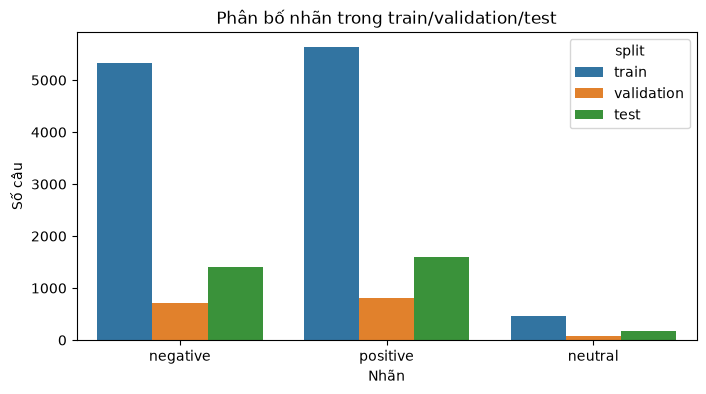

In [7]:
def label_distribution(y, split_name):
    counts = pd.Series(y).value_counts().sort_index()
    return pd.DataFrame({
        'split': split_name,
        'label_id': counts.index,
        'label_name': [CLASS_NAMES[i] for i in counts.index],
        'count': counts.values,
    })


dist_df = pd.concat([
    label_distribution(y_train, 'train'),
    label_distribution(y_val, 'validation'),
    label_distribution(y_test, 'test'),
], ignore_index=True)

display(dist_df)

plt.figure(figsize=(8, 4))
sns.barplot(data=dist_df, x='label_name', y='count', hue='split')
plt.title('Phân bố nhãn trong train/validation/test')
plt.xlabel('Nhãn')
plt.ylabel('Số câu')
plt.show()

## 7. Validation set

Code MultiChannel gốc tách 10% dữ liệu train ra làm validation. Với UIT-VSFC, dataset đã cung cấp sẵn file `UIT-VSFC_valid.csv`, nên notebook dùng trực tiếp split validation chính thức này.

Validation dùng để theo dõi mô hình trong lúc huấn luyện, phục vụ early stopping/checkpoint. Kết quả cuối cùng vẫn được báo cáo trên `UIT-VSFC_test.csv`.

In [8]:
print('Train      :', x_train.shape, y_train.shape)
print('Validation :', x_val.shape, y_val.shape)
print('Test       :', x_test.shape, y_test.shape)

Train      : (11426,) (11426,)
Validation : (1583,) (1583,)
Test       : (3166,) (3166,)


## 8. TextVectorization

Trong code gốc, bước `preprocessing.py` tạo từ điển `word2id` rồi chuyển mỗi câu thành dãy số và lưu `.npy`. Trong notebook này, `TextVectorization` làm cùng ý tưởng đó:

1. Học vocabulary từ tập train.
2. Gán mỗi token một chỉ số integer.
3. Chuyển câu chữ thành chuỗi số có độ dài cố định `MAX_LEN = 400`.

Vectorizer chỉ được `adapt` trên train set để tránh rò rỉ thông tin từ validation/test vào quá trình huấn luyện.


In [9]:
def make_vectorizer(train_texts=None):
    if train_texts is None:
        train_texts = x_train
    vectorizer = layers.TextVectorization(
        max_tokens=MAX_TOKENS,
        standardize='lower_and_strip_punctuation',
        split='whitespace',
        output_mode='int',
        output_sequence_length=MAX_LEN,
    )
    vectorizer.adapt(tf.data.Dataset.from_tensor_slices(train_texts).batch(256))
    return vectorizer


vectorizer = make_vectorizer()
vocab = vectorizer.get_vocabulary()

print('Vocabulary size:', len(vocab))
safe_print('First 20 tokens:', vocab[:20])
print('Sample sentence as token ids:')
print(vectorizer(tf.constant([x_train[0]])).numpy()[0][:40])

Vocabulary size: 2487
First 20 tokens: ['', '[UNK]', np.str_('vin'), np.str_('ging'), np.str_('dy'), np.str_('thy'), np.str_('sinh'), np.str_('hc'), np.str_('bi'), np.str_('tnh'), np.str_('khng'), np.str_('v'), np.str_('c'), np.str_('rt'), np.str_('nhit'), np.str_('cho'), np.str_('hiu'), np.str_('nhiu'), np.str_('tp'), np.str_('d')]
Sample sentence as token ids:
[120  46  52 123  91   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0]


## 9. Thiết kế mô hình CNN + LSTM theo paper

Mô hình là multi-channel vì cùng một câu đi qua hai hướng học đặc trưng:

- Nhánh CNN: dùng nhiều kernel size `3, 5, 7` để bắt các cụm từ/ngữ cảnh cục bộ có độ dài khác nhau. Sau Conv1D là GlobalMaxPooling1D, tương đương 1-max pooling trong paper.
- Nhánh LSTM: đọc câu theo thứ tự để học phụ thuộc xa và thông tin tuần tự.
- Hai vector đặc trưng được concatenate, đưa qua Dense, Dropout và Softmax 3 lớp.

So với code gốc, phần API được viết lại bằng `tf.keras`, nhưng kiến trúc và hyperparameter chính được giữ nguyên.


In [10]:
def build_cnn_lstm_model(vectorizer):
    text_input = layers.Input(shape=(), dtype=tf.string, name='text')
    token_ids = vectorizer(text_input)

    cnn_embedding = layers.Embedding(
        input_dim=MAX_TOKENS,
        output_dim=EMBEDDING_DIM,
        name='cnn_embedding',
    )(token_ids)

    cnn_features = []
    for kernel_size in CNN_KERNEL_SIZES:
        conv = layers.Conv1D(
            filters=CNN_FILTERS,
            kernel_size=kernel_size,
            activation='relu',
            padding='valid',
            name=f'conv_{kernel_size}',
        )(cnn_embedding)
        pooled = layers.GlobalMaxPooling1D(name=f'global_max_pool_{kernel_size}')(conv)
        cnn_features.append(pooled)

    cnn_channel = layers.Concatenate(name='cnn_channel')(cnn_features)

    lstm_embedding = layers.Embedding(
        input_dim=MAX_TOKENS,
        output_dim=EMBEDDING_DIM,
        name='lstm_embedding',
    )(token_ids)
    lstm_channel = layers.LSTM(LSTM_UNITS, name='lstm_channel')(lstm_embedding)

    merged = layers.Concatenate(name='cnn_lstm_concat')([lstm_channel, cnn_channel])
    dense = layers.Dense(DENSE_UNITS, activation='sigmoid', name='dense_sentiment')(merged)
    dropout = layers.Dropout(DROPOUT_RATE, name='dropout')(dense)
    output = layers.Dense(len(CLASS_NAMES), activation='softmax', name='softmax')(dropout)

    model = Model(inputs=text_input, outputs=output, name='multi_channel_cnn_lstm')
    model.compile(
        optimizer=tf.keras.optimizers.Adamax(),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model


model = build_cnn_lstm_model(vectorizer)
model.summary()

Model: "multi_channel_cnn_lstm"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text (InputLayer)   │ (None)            │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization  │ (None, 400)       │          0 │ text[0][0]        │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_embedding       │ (None, 400, 200)  │  4,308,000 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_3 (Conv1D)     │ (None, 398, 150)  │     90,150 │ cnn_embedding[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_5 (Conv1D)     │ (None, 396, 150)  │    150,150 │ cnn_embedding[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_7 (Conv1D)     │ (None, 394, 150)  │    210,150 │ cnn_embedding[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_embedding      │ (None, 400, 200)  │  4,308,000 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pool_3   │ (None, 150)       │          0 │ conv_3[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pool_5   │ (None, 150)       │          0 │ conv_5[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pool_7   │ (None, 150)       │          0 │ conv_7[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_channel (LSTM) │ (None, 128)       │    168,448 │ lstm_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_channel         │ (None, 450)       │          0 │ global_max_pool_… │
│ (Concatenate)       │                   │            │ global_max_pool_… │
│                     │                   │            │ global_max_pool_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_lstm_concat     │ (None, 578)       │          0 │ lstm_channel[0][… │
│ (Concatenate)       │                   │            │ cnn_channel[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_sentiment     │ (None, 200)       │    115,800 │ cnn_lstm_concat[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 200)       │          0 │ dense_sentiment[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax (Dense)     │ (None, 3)         │        603 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 9,351,301 (35.67 MB)

 Trainable params: 9,351,301 (35.67 MB)

 Non-trainable params: 0 (0.00 B)

## 10. Chạy thí nghiệm huấn luyện

Section này gom cả hai chế độ chạy vào một nơi:

- `RUN_5_FOLD_CV = False`: train model một lần với train/validation split chính thức của UIT-VSFC. Chế độ này dùng để chạy nhanh, kiểm tra pipeline và tạo final model để đánh giá trên test set.
- `RUN_5_FOLD_CV = True`: chạy 5-fold cross validation bằng `StratifiedKFold` trên tập train của UIT-VSFC. Mỗi fold build model mới, fit vectorizer chỉ trên train fold, lưu checkpoint của fold và đánh giá trên validation fold. Sau 5-fold, notebook train lại một final model bằng train/validation split chính thức để lưu/load và đánh giá trên test set.

Vì UIT-VSFC bị lệch nhãn khá rõ, đặc biệt lớp `neutral` ít hơn nhiều so với `positive` và `negative`, hàm train có dùng `class_weight` để giảm việc mô hình thiên về các lớp đông dữ liệu.

Checkpoint được ưu tiên lưu trong `artifacts/checkpoints/`. Nếu môi trường chạy notebook không có quyền ghi vào thư mục này, notebook tự chuyển sang thư mục tạm và in đường dẫn cụ thể. Final model được lưu ở mục 11.

In [11]:
def evaluate_model_on_data(model, x_eval, y_eval):
    y_prob = model.predict(x_eval, batch_size=BATCH_SIZE, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_eval,
        y_pred,
        average='macro',
        zero_division=0,
    )
    return {
        'accuracy': accuracy_score(y_eval, y_pred),
        'macro_precision': precision,
        'macro_recall': recall,
        'macro_f1': f1,
    }, y_pred, y_prob


def make_class_weight(y):
    classes = np.unique(y)
    weights = compute_class_weight(
        class_weight='balanced',
        classes=classes,
        y=y,
    )
    return {int(class_id): float(weight) for class_id, weight in zip(classes, weights)}


def train_model_with_validation(x_train_part, y_train_part, x_val_part, y_val_part, checkpoint_path, epochs=EPOCHS):
    tf.keras.backend.clear_session()
    vectorizer = make_vectorizer(x_train_part)
    trained_model = build_cnn_lstm_model(vectorizer)

    checkpoint_path = Path(checkpoint_path)
    checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
    if checkpoint_path.exists():
        checkpoint_path.unlink()

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            mode='max',
            patience=3,
            restore_best_weights=True,
        ),
    ]

    trained_history = trained_model.fit(
        x_train_part,
        y_train_part,
        validation_data=(x_val_part, y_val_part),
        epochs=epochs,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        class_weight=make_class_weight(y_train_part),
        verbose=2,
    )

    trained_model.save_weights(str(checkpoint_path))

    return trained_model, trained_history


def run_single_train():
    checkpoint_path = CHECKPOINT_DIR / 'vietnamese_sentiment_best.weights.h5'
    trained_model, trained_history = train_model_with_validation(
        x_train,
        y_train,
        x_val,
        y_val,
        checkpoint_path,
    )
    val_metrics, _, _ = evaluate_model_on_data(trained_model, x_val, y_val)
    validation_results = pd.DataFrame([{
        'mode': 'single_train',
        **val_metrics,
    }])
    return trained_model, trained_history, validation_results


def run_5_fold_cross_validation():
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    cv_rows = []

    for fold_id, (train_index, val_index) in enumerate(skf.split(x_train_full, y_train_full), start=1):
        print(f'===== CV Fold {fold_id}/5 =====')
        tf.random.set_seed(SEED + fold_id)

        fold_model, _ = train_model_with_validation(
            x_train_full[train_index],
            y_train_full[train_index],
            x_train_full[val_index],
            y_train_full[val_index],
            CHECKPOINT_DIR / f'cv_fold_{fold_id}_best.weights.h5',
        )
        fold_metrics, _, _ = evaluate_model_on_data(fold_model, x_train_full[val_index], y_train_full[val_index])
        cv_rows.append({'fold': fold_id, **fold_metrics})

    cv_results = pd.DataFrame(cv_rows)
    mean_row = cv_results.mean(numeric_only=True).to_frame().T
    mean_row['fold'] = 'mean'
    cv_results = pd.concat([cv_results, mean_row], ignore_index=True)

    print('===== Train final model for checkpoint/test evaluation =====')
    final_model, final_history = train_model_with_validation(
        x_train,
        y_train,
        x_val,
        y_val,
        CHECKPOINT_DIR / 'vietnamese_sentiment_best.weights.h5',
    )
    return final_model, final_history, cv_results


RUN_5_FOLD_CV = True

if RUN_5_FOLD_CV:
    model, history, experiment_results = run_5_fold_cross_validation()
else:
    model, history, experiment_results = run_single_train()

display(experiment_results)

===== CV Fold 1/5 =====

Epoch 1/14
286/286 - 55s - 193ms/step - accuracy: 0.5967 - loss: 0.8838 - val_accuracy: 0.6999 - val_loss: 0.6199
Epoch 2/14
286/286 - 54s - 188ms/step - accuracy: 0.7982 - loss: 0.5194 - val_accuracy: 0.8075 - val_loss: 0.4634
Epoch 3/14
286/286 - 54s - 190ms/step - accuracy: 0.8425 - loss: 0.4189 - val_accuracy: 0.8425 - val_loss: 0.3966
Epoch 4/14
286/286 - 54s - 189ms/step - accuracy: 0.8702 - loss: 0.3462 - val_accuracy: 0.8587 - val_loss: 0.3676
Epoch 5/14
286/286 - 55s - 191ms/step - accuracy: 0.8892 - loss: 0.2944 - val_accuracy: 0.8775 - val_loss: 0.3302
Epoch 6/14
286/286 - 54s - 190ms/step - accuracy: 0.9054 - loss: 0.2487 - val_accuracy: 0.8771 - val_loss: 0.3174
Epoch 7/14
286/286 - 53s - 187ms/step - accuracy: 0.9204 - loss: 0.2087 - val_accuracy: 0.8885 - val_loss: 0.2919
Epoch 8/14
286/286 - 52s - 183ms/step - accuracy: 0.9330 - loss: 0.1778 - val_accuracy: 0.8898 - val_loss: 0.2950
Epoch 9/14
286/286 - 52s - 180ms/step - accuracy: 0.9440 - loss

,fold,accuracy,macro_precision,macro_recall,macro_f1
0,1,0.910761,0.770579,0.794823,0.781095
1,2,0.907221,0.767707,0.760865,0.764165
2,3,0.889278,0.726467,0.738657,0.731859
3,4,0.905908,0.759982,0.798790,0.775673
4,5,0.908972,0.775355,0.814117,0.791568
5,mean,0.904428,0.760018,0.781450,0.768872


## 11. Lưu checkpoint và load lại model

Sau khi huấn luyện, notebook lưu **weights checkpoint** tại `artifacts/checkpoints/vietnamese_sentiment_best.weights.h5`.

Checkpoint này chứa trọng số tốt nhất đang nằm trong model sau `EarlyStopping(restore_best_weights=True)`. Để load lại, notebook build lại cùng kiến trúc, adapt lại `TextVectorization` từ train set, rồi nạp weights bằng `load_weights`.

Cách này tránh lỗi serialize vocabulary tiếng Việt khi lưu full `.keras` model trên một số môi trường Windows. Cell dưới đây load thử checkpoint để kiểm tra file có thể dùng lại.


In [12]:
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

final_checkpoint_path = CHECKPOINT_DIR / 'vietnamese_sentiment_best.weights.h5'
if not final_checkpoint_path.exists():
    model.save_weights(str(final_checkpoint_path))

loaded_vectorizer = make_vectorizer(x_train)
loaded_model = build_cnn_lstm_model(loaded_vectorizer)
loaded_model.load_weights(str(final_checkpoint_path))
safe_print(f'Loaded weights checkpoint from: {final_checkpoint_path}')

sample_texts = x_test[:3]
sample_probs = loaded_model.predict(sample_texts, batch_size=BATCH_SIZE, verbose=0)
sample_pred_ids = np.argmax(sample_probs, axis=1)
sample_pred_labels = [CLASS_NAMES[idx] for idx in sample_pred_ids]

for text, label in zip(sample_texts, sample_pred_labels):
    safe_print(f'Predict: {label} | Text: {text[:120]}...')

Loaded weights checkpoint from: artifacts\checkpoints\vietnamese_sentiment_best.weights.h5
Predict: positive | Text: ni ting anh lu lot ....
Predict: positive | Text: gio vin rt vui tnh ....
Predict: positive | Text: c max c tm ....


d:\Sentiment-analysis--CNN-LSTM\23127075\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adamax', because it has 2 variables whereas the saved optimizer has 32 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## 12. Theo dõi quá trình huấn luyện

Biểu đồ loss và accuracy giúp xem final model có học được hay không và có dấu hiệu overfitting không. Nếu train accuracy tăng nhưng validation accuracy giảm, mô hình đang học thuộc train set quá nhiều.


,accuracy,loss,val_accuracy,val_loss
9,0.956240,0.119782,0.914087,0.290504
10,0.965080,0.098475,0.917877,0.294027
11,0.971294,0.081044,0.917877,0.302189
12,0.976457,0.066934,0.917246,0.312375
13,0.981183,0.053046,0.919141,0.327872


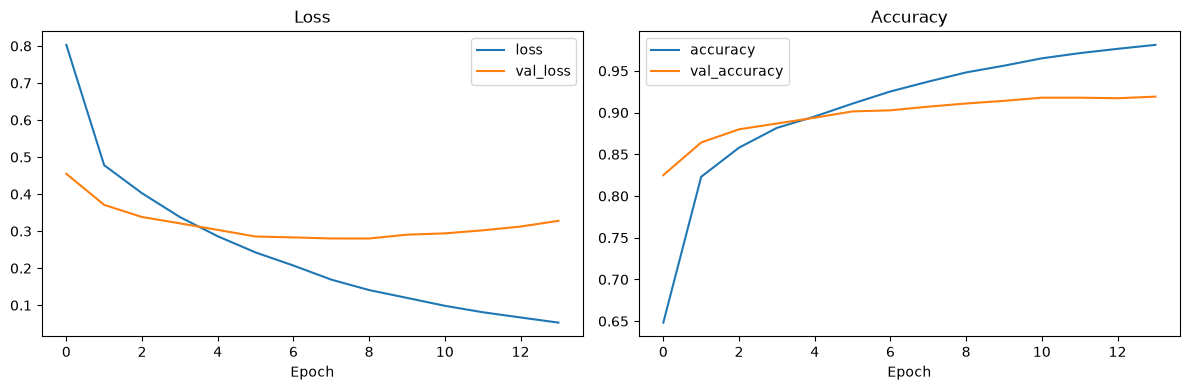

In [13]:
history_df = pd.DataFrame(history.history)
display(history_df.tail())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
history_df[['loss', 'val_loss']].plot(ax=axes[0])
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')

history_df[['accuracy', 'val_accuracy']].plot(ax=axes[1])
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')

plt.tight_layout()
plt.show()


## 13. Đánh giá performance trên test set

Test set chỉ dùng sau khi train xong để báo cáo kết quả cuối cùng. Các chỉ số được báo cáo gồm:

- Accuracy
- Macro precision, recall, F1-score
- Classification report theo từng lớp
- Confusion matrix


In [14]:
test_metrics, y_pred, test_prob = evaluate_model_on_data(model, x_test, y_test)

test_result = pd.DataFrame([{
    'dataset': 'UIT-VSFC test',
    **test_metrics,
}])

display(test_result)
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=4))

,dataset,accuracy,macro_precision,macro_recall,macro_f1
0,UIT-VSFC test,0.891661,0.757718,0.743325,0.749629


              precision    recall  f1-score   support

    negative     0.8927    0.9326    0.9122      1409
    positive     0.9322    0.9082    0.9200      1590
     neutral     0.4483    0.3892    0.4167       167

    accuracy                         0.8917      3166
   macro avg     0.7577    0.7433    0.7496      3166
weighted avg     0.8891    0.8917    0.8900      3166



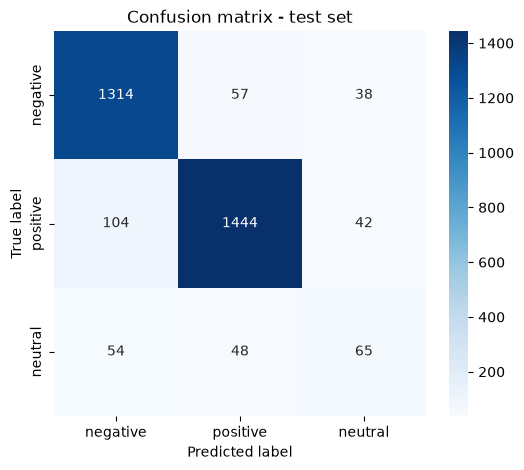

In [15]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion matrix - test set')
plt.show()


## 14. Kết luận

Notebook đã thực hiện đầy đủ pipeline cho bài toán sentiment analysis tiếng Việt: dùng dataset UIT-VSFC trong `data`, load dữ liệu CSV, tiền xử lý văn bản, xây dựng kiến trúc multi-channel CNN + LSTM theo bài báo, huấn luyện mô hình và báo cáo performance bằng các metric phân loại văn bản.

Điểm cần lưu ý là UIT-VSFC bị lệch nhãn: lớp `neutral` ít hơn nhiều so với `positive` và `negative`. Vì vậy notebook dùng `class_weight` khi huấn luyện để giảm thiên lệch về các lớp nhiều mẫu.

## 15. Citation

Notebook này tham khảo kiến trúc và implementation từ repository MultiChannel của nhóm tác giả. Theo yêu cầu trong `MultiChannel/README.md`, khi sử dụng implementation này cần cite paper sau:

```bibtex
@INPROCEEDINGS{Quan,
    author={Q. H. Vo and H. T. Nguyen and B. Le and M. L. Nguyen},
    booktitle={2017 9th International Conference on Knowledge and Systems Engineering (KSE)},
    title={Multi-channel LSTM-CNN model for Vietnamese sentiment analysis},
    year={2017},
    pages={24-29},
    keywords={Analytical models;Feature extraction;Logic gates;Machine learning;Neural networks;Sentiment analysis},
    doi={10.1109/KSE.2017.8119429},
    month={Oct},
}
```

Dataset UIT-VSFC được lấy từ Hugging Face/local repo `UIT-VSFC`. Khi sử dụng dataset này cần cite công trình gốc:

```text
Kiet Van Nguyen, Vu Duc Nguyen, Phu Xuan-Vinh Nguyen, Tham Thi-Hong Truong, Ngan Luu-Thuy Nguyen, UIT-VSFC: Vietnamese Students' Feedback Corpus for Sentiment Analysis, 2018 10th International Conference on Knowledge and Systems Engineering (KSE 2018), November 1-3, 2018, Ho Chi Minh City, Vietnam.
```

Nguồn dataset tham khảo: https://huggingface.co/datasets/ura-hcmut/UIT-VSFC